# Data exploration and graph construction
Datasets:
- F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872
- [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

In [1]:
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split

### Data exploration

In [2]:
cleaned_df = pd.read_csv('datasets/cleaned_tmdb_dataset/tmdb_with_imdb_id.csv')
cleaned_df.head()

,tmdb_id,original_title,release_year,tconst,titleType,primaryTitle,originalTitle,startYear
0,19995,Avatar,2009.0,tt0499549,movie,Avatar,Avatar,2009.0
1,285,Pirates of the Caribbean: At World's End,2007.0,tt0449088,movie,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,2007.0
2,206647,Spectre,2015.0,tt2379713,movie,Spectre,Spectre,2015.0
3,49026,The Dark Knight Rises,2012.0,tt1345836,movie,The Dark Knight Rises,The Dark Knight Rises,2012.0
4,49529,John Carter,2012.0,tt0401729,movie,John Carter,John Carter,2012.0


In [3]:
cleaned_df.columns

Index(['tmdb_id', 'original_title', 'release_year', 'tconst', 'titleType',
       'primaryTitle', 'originalTitle', 'startYear'],
      dtype='str')

In [4]:
zf = zipfile.ZipFile('datasets/grouplens_ratings/ml-32m.zip')
zf.namelist()

['ml-32m/',
 'ml-32m/tags.csv',
 'ml-32m/links.csv',
 'ml-32m/README.txt',
 'ml-32m/checksums.txt',
 'ml-32m/ratings.csv',
 'ml-32m/movies.csv']

In [5]:
ratings = pd.read_csv(zf.open('ml-32m/ratings.csv'), usecols=['userId', 'movieId', 'rating'])
ratings.head()

,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


In [6]:
print('Number of ratings:', ratings.shape[0])
print('Number of unique users:', ratings['userId'].nunique())
print('Number of unique movies:', ratings['movieId'].nunique())

Number of ratings: 32000204
Number of unique users: 200948
Number of unique movies: 84432


In [7]:
ratings = ratings[ratings['movieId'].isin(cleaned_df['tmdb_id'])]
print('Number of ratings after bisecting datasets:', ratings.shape[0])
print('Number of unique users after bisecting datasets:', ratings['userId'].nunique())
print('Number of unique movies after bisecting datasets:', ratings['movieId'].nunique())
print('Number of unique users with at least 30 ratings:', ratings[ratings['userId'].isin(ratings['userId'].value_counts()[ratings['userId'].value_counts() >= 30].index)]['userId'].nunique())

Number of ratings after bisecting datasets: 4668119
Number of unique users after bisecting datasets: 197462
Number of unique movies after bisecting datasets: 1373
Number of unique users with at least 30 ratings: 46236


In [8]:
ratings = ratings[ratings['userId'].isin(ratings['userId'].value_counts()[ratings['userId'].value_counts() >= 10].index)]
print('Number of ratings after filtering:', ratings.shape[0])
print('Number of unique users after filtering:', ratings['userId'].nunique())
print('Number of unique movies after filtering:', ratings['movieId'].nunique())

Number of ratings after filtering: 4276088
Number of unique users after filtering: 117497
Number of unique movies after filtering: 1369


In [9]:
print('Max rating:', ratings['rating'].max())
print('Min rating:', ratings['rating'].min())

Max rating: 5.0
Min rating: 0.5


In [10]:
cleaned_df = cleaned_df[cleaned_df['tmdb_id'].isin(ratings['movieId'])]
print('Number of movies in cleaned dataset after bisecting:', cleaned_df.shape[0])

Number of movies in cleaned dataset after bisecting: 1369


In [11]:
ratings_x, ratings_y = train_test_split(ratings, test_size=0.8, random_state=42, stratify=ratings['userId'])
print('Number of prompt ratings:', ratings_x.shape[0])
print('Number of ratings to predict:', ratings_y.shape[0])

Number of prompt ratings: 855217
Number of ratings to predict: 3420871


In [12]:
ratings_x.to_csv('datasets/ratings_x.csv', index=False)
ratings_y.to_csv('datasets/ratings_y.csv', index=False)

### Add movie metadata

In [13]:
movie_metadata = pd.read_csv('datasets/tmdb_movie_metadata/tmdb_5000_movies.csv')
movie_metadata.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [14]:
movies_df = pd.merge(cleaned_df, movie_metadata, left_on='tmdb_id', right_on='id', how='inner')

In [15]:
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tmdb_id               1369 non-null   int64  
 1   original_title_x      1369 non-null   str    
 2   release_year          1369 non-null   float64
 3   tconst                1369 non-null   str    
 4   titleType             1369 non-null   str    
 5   primaryTitle          1369 non-null   str    
 6   originalTitle         1369 non-null   str    
 7   startYear             1369 non-null   float64
 8   budget                1369 non-null   int64  
 9   genres                1369 non-null   str    
 10  homepage              526 non-null    str    
 11  id                    1369 non-null   int64  
 12  keywords              1369 non-null   str    
 13  original_language     1369 non-null   str    
 14  original_title_y      1369 non-null   str    
 15  overview              1368 non-n

In [16]:
import pandas as pd

# Popis stupaca koje smo odlučili ukloniti na temelju analize
stupci_za_izbacivanje = [
    'original_title_x', 
    'original_title_y', 
    'release_year',    # Zadržavamo startYear ili release_date
    'titleType',       # Pretpostavka da su sve 'movie'
    'homepage',        # Previše nedostajućih vrijednosti, beskorisno za preporuke
    'id',              # Redundantni ID pokraj tmdb_id i tconst
    'status',          # Status distribucije, nebitno za preporuku
    'tagline'          # Kratki marketinški tekst, imamo već 'overview'
]

movies_df = movies_df.drop(columns=stupci_za_izbacivanje)

print(movies_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tmdb_id               1369 non-null   int64  
 1   tconst                1369 non-null   str    
 2   primaryTitle          1369 non-null   str    
 3   originalTitle         1369 non-null   str    
 4   startYear             1369 non-null   float64
 5   budget                1369 non-null   int64  
 6   genres                1369 non-null   str    
 7   keywords              1369 non-null   str    
 8   original_language     1369 non-null   str    
 9   overview              1368 non-null   str    
 10  popularity            1369 non-null   float64
 11  production_companies  1369 non-null   str    
 12  production_countries  1369 non-null   str    
 13  release_date          1369 non-null   str    
 14  revenue               1369 non-null   int64  
 15  runtime               1369 non-n

In [18]:
credits_df = pd.read_csv('datasets/tmdb_movie_metadata/tmdb_5000_credits.csv')
credits_df = credits_df[credits_df['movie_id'].isin(movies_df['tmdb_id'])]
credits_df.head()

,movie_id,title,cast,crew
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
5,559,Spider-Man 3,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de..."
8,767,Harry Potter and the Half-Blood Prince,"[{""cast_id"": 3, ""character"": ""Harry Potter"", ""...","[{""credit_id"": ""52fe4273c3a36847f801fab1"", ""de..."
12,58,Pirates of the Caribbean: Dead Man's Chest,"[{""cast_id"": 37, ""character"": ""Captain Jack Sp...","[{""credit_id"": ""52fe4211c3a36847f8001873"", ""de..."


### Build graph

In [19]:
import igraph as ig
import ast
import pandas as pd

# --- 1. KORAK: Priprema jedinstvenih imena i mapiranje ---
# Koristimo iste prefikse ('movie_' i 'person_') kako bismo izbjegli Name Clashing
movie_names_set = set()
person_names_set = set()
edges_tuples = []

# Prolazak kroz filmove i kreiranje skupova
for _, row in movies_df.iterrows():
    if pd.isna(row['title']):
        continue
    movie_names_set.add(f"movie_{row['title']}")

# Prolazak kroz credits za prikupljanje osoba i veza
for _, row in credits_df.iterrows():
    title = row['title']
    if pd.isna(title):
        continue
    m_id = f"movie_{title}"
    if m_id not in movie_names_set:
        continue
        
    try:
        cast = ast.literal_eval(row['cast']) if isinstance(row['cast'], str) else (row['cast'] or [])
    except Exception:
        cast = []
    try:
        crew = ast.literal_eval(row['crew']) if isinstance(row['crew'], str) else (row['crew'] or [])
    except Exception:
        crew = []
        
    for member in cast:
        if isinstance(member, dict) and member.get('name'):
            p_id = f"person_{member['name']}"
            person_names_set.add(p_id)
            edges_tuples.append((m_id, p_id))
            
    for member in crew:
        if isinstance(member, dict) and member.get('name'):
            p_id = f"person_{member['name']}"
            person_names_set.add(p_id)
            edges_tuples.append((m_id, p_id))

# --- 2. KORAK: Mapiranje stringova u numeričke ID-jeve (0, 1, 2...) ---
all_movies = list(movie_names_set)
all_people = list(person_names_set)
all_nodes = all_movies + all_people

# Kreiramo rječnik za brzo pretraživanje indeksa čvora: {"movie_Avatar": 0, ...}
node_to_idx = {name: idx for idx, name in enumerate(all_nodes)}

# Definiramo 'type' atribut (bipartite): False (0) za filmove, True (1) za ljude
# igraph prepoznaje bipartitnost preko boolean (True/False) atributa 'type'
node_types = [False] * len(all_movies) + [True] * len(all_people)

# Prebacujemo tekstualne bridove u numeričke indekse
numerical_edges = [(node_to_idx[m], node_to_idx[p]) for m, p in edges_tuples]

# --- 3. KORAK: Kreiranje igraph Grafa ---
g = ig.Graph(n=len(all_nodes), edges=numerical_edges)

# Dodjeljivanje ključnih atributa čvorovima
g.vs["name"] = all_nodes       # originalni ID s prefiksom
g.vs["type"] = node_types     # bipartitni tip (obavezno nazvati 'type')

# --- PROVJERA 1 ---
print("Is original graph bipartite:", g.is_bipartite())

# --- 4. KORAK: Izvlačenje najveće povezane komponente ---
# igraph je ovdje ekstremno brz jer vraća direktno podgraf
components = g.connected_components(mode="weak")
max_component = components.subgraph(max(range(len(components)), key=lambda i: len(components[i])))

# --- PROVJERA 2 ---
print("Is largest component bipartite:", max_component.is_bipartite())
print(f"Number of nodes in largest component: {max_component.vcount()}")

Is original graph bipartite: True
Is largest component bipartite: True
Number of nodes in largest component: 50541


Računam raspored za maketu od 7555 čvorova...


c:\Users\nikol\Desktop\recommendation-system-graph\.venv\Lib\site-packages\igraph\layout.py:705: RuntimeWarning: LGL layout does not support disconnected graphs yet. Location: src/layout/large_graph.c:175
  layout = func(*args, **kwds)


Gotovo! Crtam graf...


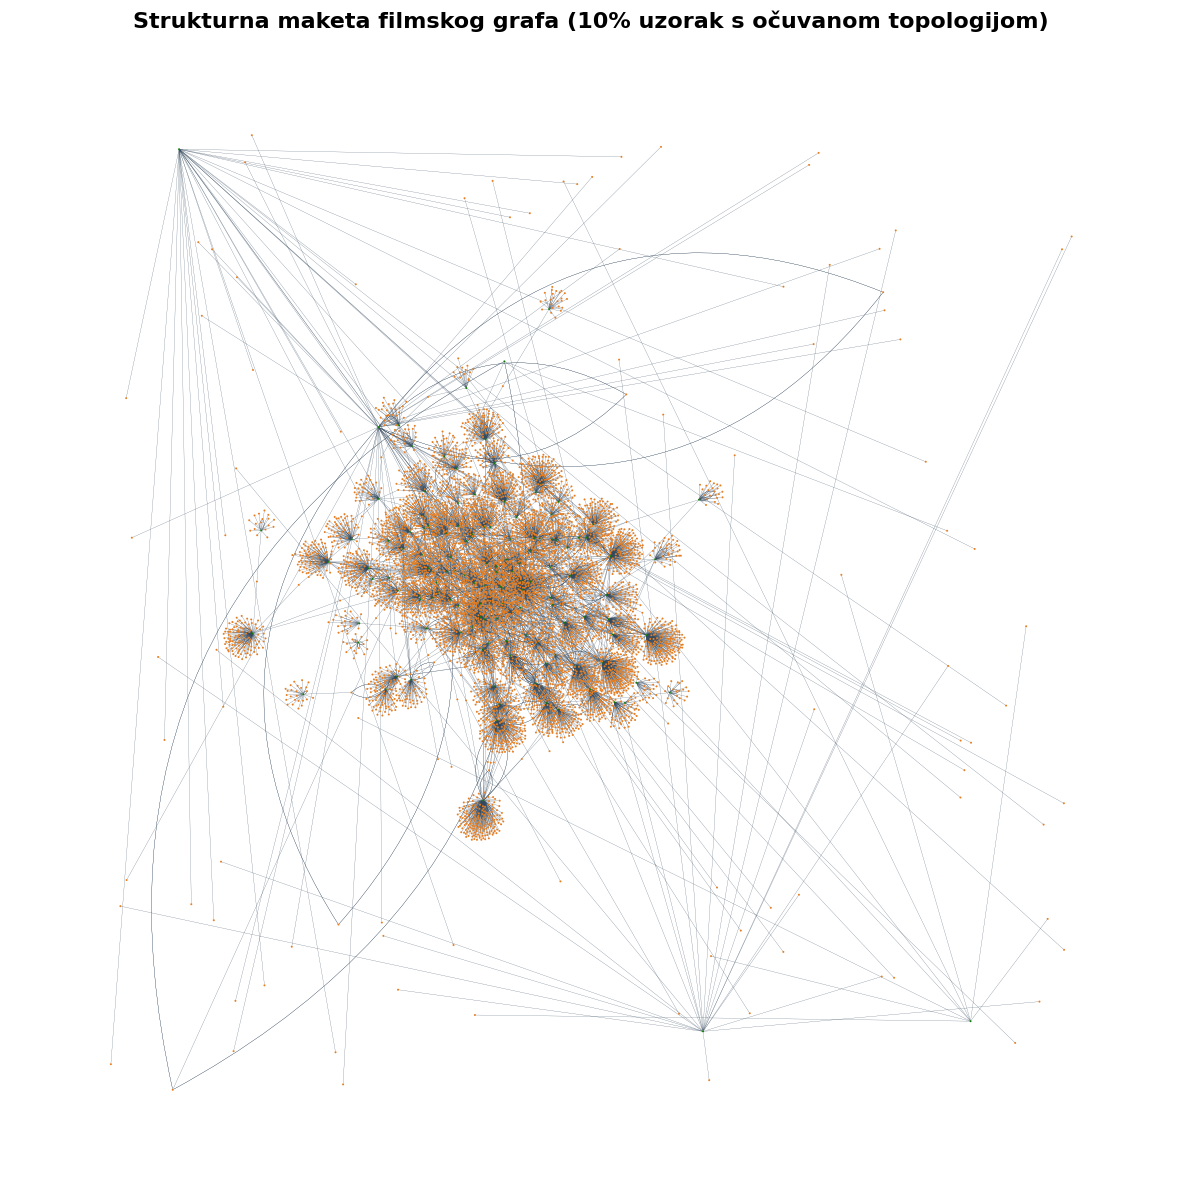

In [20]:
import random
import matplotlib.pyplot as plt

# 1. Uzorkovanje: Uzimamo npr. 10% svih filmova da zadržimo globalnu strukturu
svi_filmovi = [v.index for v in max_component.vs if "movie_" in v["name"]]
broj_uzoraka = int(len(svi_filmovi) * 0.10) # 10% je savršen omjer brzine i izgleda
uzorkovani_filmovi_indeksi = random.sample(svi_filmovi, broj_uzoraka)

# Pronalazimo sve ljude (glumce/crew) koji su povezani s tim filmovima
connected_people_idx = set()
for f_idx in uzorkovani_filmovi_indeksi:
    connected_people_idx.update(max_component.neighbors(f_idx))

# Spajamo sve u jedan skup čvorova za podgraf
all_sampled_idx = list(set(uzorkovani_filmovi_indeksi).union(connected_people_idx))

# Stvaramo podgraf koji je vjerna "maketa" velikog grafa
visualization_subgraph = max_component.subgraph(all_sampled_idx)

# 2. Postavljanje vizualnih atributa (filmovi plavi, ljudi narančasti)
visualization_subgraph.vs["color"] = ["#127a06" if "movie_" in n else "#e67e22" for n in visualization_subgraph.vs["name"]]
visualization_subgraph.vs["size"] = 2.0  # malo veći čvorovi da se bolje vide u podgrafu
visualization_subgraph.vs["label"] = None

# 3. Brzi proračun rasporeda (izvršava se trenutno)
print(f"Računam raspored za maketu od {visualization_subgraph.vcount()} čvorova...")
layout = visualization_subgraph.layout("lgl") # LGL je ekstremno brz za ovakve podgrafove
print("Gotovo! Crtam graf...")

# 4. Iscrtavanje
fig, ax = plt.subplots(figsize=(15, 15))
ig.plot(
    visualization_subgraph,
    target=ax,
    layout=layout,
    edge_color="#34495e",
    edge_width=0.15,
    vertex_frame_width=0
)

plt.title("Strukturna maketa filmskog grafa (10% uzorak s očuvanom topologijom)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

### Save graph in CSV for quickload

In [21]:
edges_indices = max_component.to_tuple_list()

edge_list_names = [
    (max_component.vs[src]["name"], max_component.vs[tgt]["name"])
    for src, tgt in edges_indices
]

edges_df = pd.DataFrame(edge_list_names, columns=["source", "target"])
edges_df.to_csv("datasets/graph_edges.csv", index=False)

print("Graph edges are successfully saved to 'datasets/graph_edges.csv'!")

Graph edges are successfully saved to 'datasets/graph_edges.csv'!
